In [405]:
import numpy as np
import matplotlib.pyplot as plt

In [406]:
sum(nums), sum(nums_2)

(5027.932053854689, 75000)

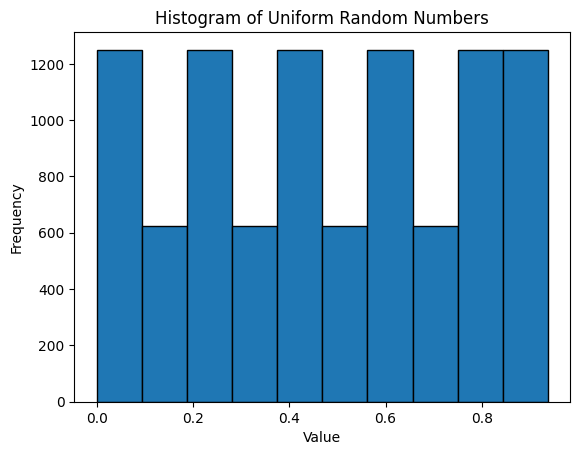

In [407]:
a = 5
c = 1
seed = 3  # Example seed value
m = 16 # 65536
n = 10000  # Number of random numbers to generate
bins = 10

class LCG:
    def __init__(self, seed, a=a, c=c, m=m):
        self.seed = seed
        self.a = a  # Degrees of freedom
        self.c = c
        self.m = m

    def next(self):
        """Generate the next random number starting from the current seed"""
        self.seed = (self.a * self.seed + self.c) % self.m
        return self.seed / self.m   # Normalize to [0, 1]
    
    def next_int(self):
        """Generate the next random integer starting from the current seed"""
        self.seed = (self.a * self.seed + self.c) % self.m
        return self.seed  # Return the raw integer value
    
    def next_n(self, n):
        """Generate the next n random numbers"""
        return [self.seed / self.m] + [self.next() for _ in range(n-1)]
    
    def next_n_int(self, n):
        """Generate the next n random integers"""
        return [self.seed] + [self.next_int() for _ in range(n-1)]




Generator = LCG(seed=seed, a=a, c=c, m=m)
nums = list(Generator.next_n(n))
nums_2 = list(Generator.next_n_int(n))

plt.hist(nums, bins=bins, edgecolor='black')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of Uniform Random Numbers')
plt.show()


Descriptive tests

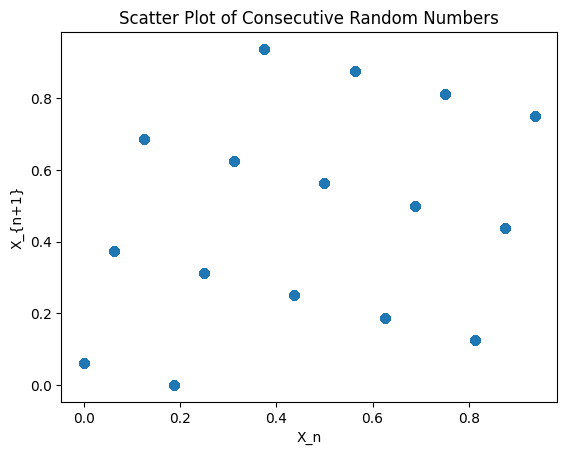

In [408]:
scatter_nums = np.array(nums)
plt.scatter(scatter_nums[:-1], scatter_nums[1:], alpha=0.5)
plt.xlabel('X_n')
plt.ylabel('X_{n+1}')
plt.title('Scatter Plot of Consecutive Random Numbers')
plt.show()

In [409]:
def chi_2_test(nums, m, bins=bins):
    """Perform a chi-squared test for uniformity"""
    observed, _ = np.histogram(nums, bins=bins)
    expected = len(nums) / bins
    chi_squared_stat = np.sum((observed - expected) ** 2 / expected)
    return chi_squared_stat

chi_squared_stat = chi_2_test(nums, m)
print(f"Chi-squared statistic: {chi_squared_stat}")

def chi_2_distribution(k):
    """Calculate the chi-squared distribution value for k degrees of freedom"""
    from scipy.stats import chi2
    return chi2.ppf(0.95, df=k)

k = bins - 1 # Degrees of freedom
chi_squared_critical = chi_2_distribution(k)
# print(f"Chi-squared critical value at 95% confidence: {chi_squared_critical}")
print(f"chi_squared_stat: {chi_squared_stat}, chi_squared_critical: {chi_squared_critical}")
if chi_squared_stat < chi_squared_critical:
    print("Fail to reject the null hypothesis: The numbers are uniformly distributed, meaning they are random.")
else:
    print("Reject the null hypothesis: The numbers are not uniformly distributed, meaning they are not random.")

Chi-squared statistic: 937.5
chi_squared_stat: 937.5, chi_squared_critical: 16.918977604620448
Reject the null hypothesis: The numbers are not uniformly distributed, meaning they are not random.


In [436]:
from scipy.stats import ksone

def kolomogorov_smirnov_test(nums, case):
    """Perform a Kolmogorov-Smirnov test for uniformity"""
    n = len(nums)
    sorted_nums = np.sort(nums)
    
    empirical_cdf = np.arange(1, n + 1) / n
    empirical_cdf_prev = np.arange(0, n) / n
    theoretical_cdf = sorted_nums  
    
    # Must check distance at both the top and bottom of the empirical steps
    D_plus = np.max(empirical_cdf - theoretical_cdf)
    D_minus = np.max(theoretical_cdf - empirical_cdf_prev)
    D = max(D_plus, D_minus)

    if case == 'known':
        adjusted_D = (np.sqrt(n) + 0.12 + 0.11 / np.sqrt(n)) * D
    if case == 'normal':
        adjusted_D = (np.sqrt(n) - 0.01 + 0.85 / np.sqrt(n)) * D
        return adjusted_D
    if case == 'exp':
        adjusted_D = (np.sqrt(n) + 0.26 + 0.05 / np.sqrt(n)) * (D - 0.2 / np.sqrt(n))
        return adjusted_D
    
    return D

def kolomogorov_smirnov_distribution(n):
    # To get the critical value
    return ksone.ppf(0.95, n)

D = kolomogorov_smirnov_test(nums, case='known')
D_critical = kolomogorov_smirnov_distribution(n)
print(f"Kolmogorov-Smirnov statistic: {D}")
print(f"Kolmogorov-Smirnov critical value at 95% confidence: {D_critical}")
if D < D_critical:
    print("The null hypothesis of uniformity cannot be rejected, the numbers are not random.")
else:    
    print("The null hypothesis of uniformity is rejected. The numbers are not random.")

Kolmogorov-Smirnov statistic: 0.003680120481927729
Kolmogorov-Smirnov critical value at 95% confidence: 0.012222011278849367
The null hypothesis of uniformity cannot be rejected, the numbers are not random.


In [411]:
def wald_wolfowitz_runs_test(nums):
    """Perform the Wald-Wolfowitz runs test for randomness"""
    median = np.median(nums)
    runs = 1
    for i in range(1, len(nums)):
        if (nums[i] > median) != (nums[i-1] > median):
            runs += 1
    n1 = np.sum(nums > median) # upper half
    n2 = np.sum(nums <= median) # lower half
    
    expected_runs = 2 * n1 * n2 / (n1 + n2) + 1
    variance_runs = (expected_runs - 1) * (expected_runs - 2) / (n1 + n2 - 1)
    print(f"Runs: {runs}, Expected Runs: {expected_runs}, Variance of Runs: {variance_runs}")
    # calculate the z-score which is 
    z = (runs - expected_runs) / np.sqrt(variance_runs)
    return z

z = wald_wolfowitz_runs_test(nums)
print(f"Wald-Wolfowitz runs test statistic (z): {z}")
if abs(z) < 1.96:  # 95% confidence interval
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    
    print("Reject the null hypothesis: The sequence is not random.")

Runs: 3750, Expected Runs: 5001.0, Variance of Runs: 2499.7499749975
Wald-Wolfowitz runs test statistic (z): -25.0212512189641
Reject the null hypothesis: The sequence is not random.


In [412]:
# import numpy as np



In [413]:
def up_down_knuth_test(nums):

    T = 1
    run_length = []
    start = 1
    for i in range(1,len(nums)):
        if nums[i] < nums[i-1]:
            T += 1
            run_length.append(start)
            start = 1
        else:
            start += 1
    run_length.append(start)

    R = np.zeros(6)

    for r in run_length:
        if r >= 6:
            R[5] += 1
        else:
            R[r - 1] += 1

    
    n = len(nums)

    A = np.array([
    [4529.4, 9044.9, 13568, 18091, 22615, 27892],
    [9044.9, 18097, 27139, 36187, 45234, 55789],
    [13568, 27139, 40721, 54281, 67852, 83685],
    [18091, 36187, 54281, 72414, 90470, 111580],
    [22615, 45234, 67852, 90470, 113262, 139476],
    [27892, 55789, 83685, 111580, 139476, 172860]])

    B = np.array([1/6, 5/24, 11/120, 19/720, 29/5040, 1/840])

    D = (R - n * B)

    Z = 1/(n - 6) * (D.T @ A @ D)

    return Z


Z = up_down_knuth_test(nums)
print(f"Up-Down Knuth test statistic (Z): {Z}")
if Z < 11.07:  # Chi-squared critical value for 5 degrees of freedom at 95% confidence
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    print("Reject the null hypothesis: The sequence is not random.")

    

Up-Down Knuth test statistic (Z): 1118.826845364202
Reject the null hypothesis: The sequence is not random.


In [414]:
import numpy as np

def up_down_knuth_test(nums):
    """Perform the Up-Down Knuth test for randomness"""
    up_down_sequence = [1 if nums[i] > nums[i-1] else 0 for i in range(1, len(nums))]
    # A run is a segment of identical signs
    if not up_down_sequence:
        return None

    runs = 1
    for i in range(1, len(up_down_sequence)):
        if up_down_sequence[i] != up_down_sequence[i-1]:
            runs += 1
    n = len(nums)

    expected_runs = (2 * n - 1) / 3
    variance_runs = (16 * n - 29) / 90
    print(f"Runs: {runs}, Expected Runs: {expected_runs}, Variance of Runs: {variance_runs}, n: {n}")
    z = (runs - expected_runs) / np.sqrt(variance_runs)
    return z

z = up_down_knuth_test(nums)
print(f"Up-Down Knuth test statistic (z): {z}")
if abs(z) < 1.96:  # 95% confidence interval
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    
    print("Reject the null hypothesis: The sequence is not random.")

Runs: 6250, Expected Runs: 6666.333333333333, Variance of Runs: 1777.4555555555555, n: 10000
Up-Down Knuth test statistic (z): -9.875106965999812
Reject the null hypothesis: The sequence is not random.


In [415]:
def correlation_test(nums, h=1):
    """Perform a correlation test for randomness"""
    n = len(nums)
    sum = 0
    for i in range(n - h):
        sum += nums[i] * nums[i + h]
    corr = sum / (n - h)

    expected_corr = 1/4
    expected_variance = 7/(144*n)
    print(corr)
    z = (corr - expected_corr) / np.sqrt(expected_variance)
    return z

z = correlation_test(nums, h=1)
print(f"Correlation test statistic: {z}")
if abs(z) < 1.96:  # Threshold for correlation test (95% confidence)
    print("Fail to reject the null hypothesis: The sequence is random.")
else:    print("Reject the null hypothesis: The sequence is not random.")

0.242200001250125
Correlation test statistic: -3.537746900362962
Reject the null hypothesis: The sequence is not random.


Runs: 3750, Expected Runs: 5001.0, Variance of Runs: 2499.7499749975
Runs: 6250, Expected Runs: 6666.333333333333, Variance of Runs: 1777.4555555555555, n: 10000
0.302734375

Parameters: {'seed': 3, 'a': 5, 'c': 1, 'm': 16}
  Chi-squared               : ❌ FAIL  (stat: 937.50, crit: 16.92)
  Kolmogorov-Smirnov        : ❌ FAIL  (stat: 0.0625, crit: 0.0122)
  Wald-Wolfowitz            : ❌ FAIL  (z: -25.02)
  Up-Down runs              : ❌ FAIL  (z: -9.88)
  Correlation (h=5)         : ❌ FAIL  (z: 23.92)
---------------------------------------------------------------------------
Runs: 4974, Expected Runs: 5001.0, Variance of Runs: 2499.7499749975
Runs: 6594, Expected Runs: 6666.333333333333, Variance of Runs: 1777.4555555555555, n: 10000
0.2503255561065597

Parameters: {'seed': 2, 'a': 40014, 'c': 0, 'm': 2147483563}
  Chi-squared               : ✅ PASS  (stat: 10.95, crit: 16.92)
  Kolmogorov-Smirnov        : ✅ PASS  (stat: 0.0088, crit: 0.0122)
  Wald-Wolfowitz            : ✅ PASS  (z: -0

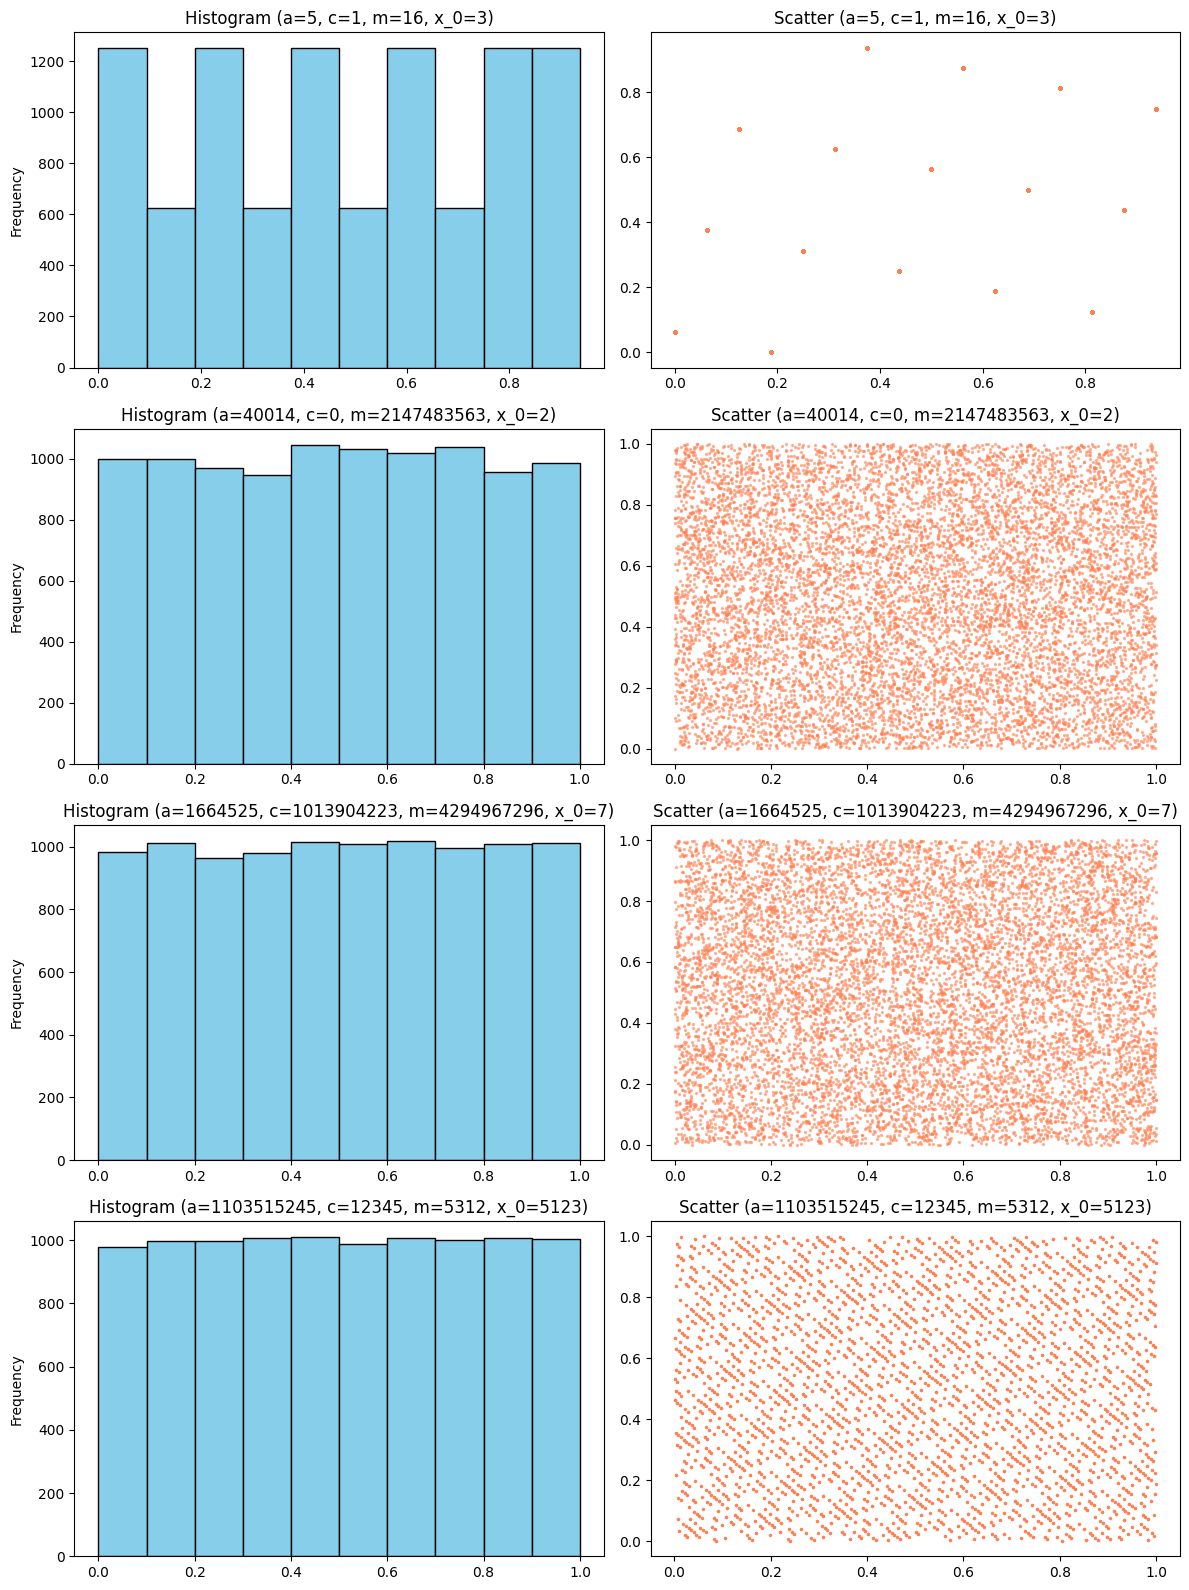

In [444]:
import matplotlib.pyplot as plt

# Define different sets of parameters for the LCG (including poor and good ones)
parameter_sets = [
    {'seed': 3, 'a': 5, 'c': 1, 'm': 16},           # Original
    {'seed': 2, 'a': 40014, 'c': 0, 'm': 2147483563},                    # Poor parameters (very small m)
    {'seed': 7, 'a': 1664525, 'c': 1013904223, 'm': 2**32},      # Numerical Recipes (good parameters)
    {'seed': 5123, 'a': 1103515245, 'c': 12345, 'm': 5312}     # glibc (good parameters)
]

n = 10000

# Create subplots setup
fig, axes = plt.subplots(len(parameter_sets), 2, figsize=(12, 4 * len(parameter_sets)))

for i, params in enumerate(parameter_sets):
    # Generate numbers with the current parameter set
    gen = LCG(seed=params['seed'], a=params['a'], c=params['c'], m=params['m'])
    nums = list(gen.next_n(n))
    
    # Run tests on the generated numbers
    chi2 = chi_2_test(nums, params['m'])
    ks = kolomogorov_smirnov_test(nums, case='known')
    ww = wald_wolfowitz_runs_test(nums)
    try:
        ud = up_down_knuth_test(nums)
    except NameError:
        ud = up_down_knuth_test(nums)
    
    chi2_crit = chi_2_distribution(9)
    ks_crit = kolomogorov_smirnov_distribution(n)
    corr = correlation_test(nums, h=16)
    
    # Output the test results
    print(f"\nParameters: {params}")
    print(f"  Chi-squared               : {'✅ PASS' if chi2 < chi2_crit else '❌ FAIL'}  (stat: {chi2:.2f}, crit: {chi2_crit:.2f})")
    print(f"  Kolmogorov-Smirnov        : {'✅ PASS' if ks < ks_crit else '❌ FAIL'}  (stat: {ks:.4f}, crit: {ks_crit:.4f})")
    print(f"  Wald-Wolfowitz            : {'✅ PASS' if abs(ww) < 1.96 else '❌ FAIL'}  (z: {ww:.2f})")
    print(f"  Up-Down runs              : {'✅ PASS' if abs(ud) < 1.96 else '❌ FAIL'}  (z: {ud:.2f})")
    print(f"  Correlation (h=5)         : {'✅ PASS' if abs(corr) < 1.96 else '❌ FAIL'}  (z: {corr:.2f})")
    print("-" * 75)
    
    # Plot 1: Histogram
    axes[i, 0].hist(nums, bins=10, edgecolor='black', color='skyblue')
    axes[i, 0].set_title(f"Histogram (a={params['a']}, c={params['c']}, m={params['m']}, x_0={params['seed']})")
    axes[i, 0].set_ylabel('Frequency')
    
    # Plot 2: Scatter plot of consecutive values
    scatter_nums = np.array(nums)
    axes[i, 1].scatter(scatter_nums[:-1], scatter_nums[1:], alpha=0.5, s=2, color='coral')
    axes[i, 1].set_title(f"Scatter (a={params['a']}, c={params['c']}, m={params['m']}, x_0={params['seed']})")

plt.tight_layout()
plt.savefig("lcg_comparison.png")
plt.show()
